In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
# Load datasets
products_df = pd.read_csv('products.csv')
sales_df = pd.read_csv('sales_transactions.csv')
feedback_df = pd.read_csv('customer_feedback.csv')

In [ ]:
# Handle missing values
sales_df.dropna(subset=['TransactionDate', 'ProductID', 'Quantity'], inplace=True)
feedback_df.fillna({'Rating': feedback_df['Rating'].mean()}, inplace=True)

In [ ]:
# Merge datasets
merged_df = pd.merge(sales_df, products_df, on='ProductID')
merged_df = pd.merge(merged_df, feedback_df, on=['CustomerID', 'ProductID'], how='left')

In [ ]:
merged_df.describe()

,TransactionID,ProductID,Quantity,CustomerID,Price,FeedbackID,Rating
count,83.000000,83.000000,83.000000,83.000000,83.00000,20.000000,20.000000
mean,48.831325,5.903614,4.915663,10.807229,36.26506,21.100000,3.150000
std,29.839334,2.657775,2.538507,6.165320,11.78681,10.622221,1.348488
min,1.000000,1.000000,1.000000,1.000000,15.00000,5.000000,1.000000
25%,23.500000,4.000000,3.000000,5.000000,30.00000,11.500000,2.000000
50%,48.000000,6.000000,5.000000,12.000000,40.00000,23.000000,3.000000
75%,74.500000,8.000000,7.000000,16.000000,45.00000,27.500000,4.000000
max,100.000000,10.000000,9.000000,20.000000,55.00000,43.000000,5.000000


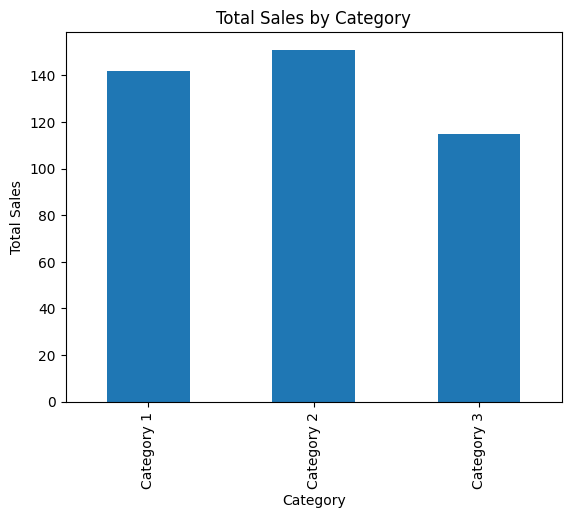

In [ ]:
# Sales by category
sales_by_category = merged_df.groupby('Category')['Quantity'].sum()
sales_by_category.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

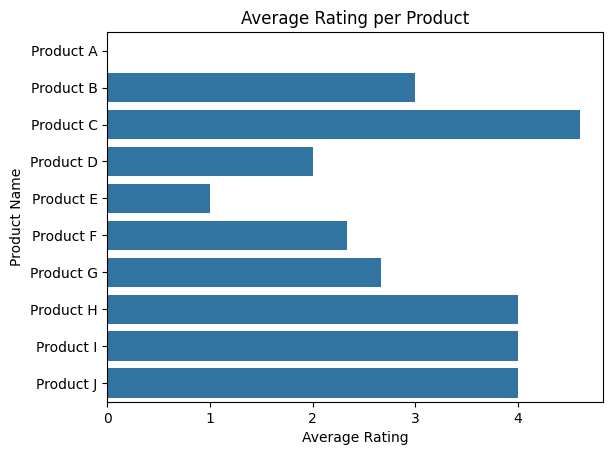

In [ ]:
# Average rating per product
avg_rating_per_product = merged_df.groupby('ProductName')['Rating'].mean()
sns.barplot(x=avg_rating_per_product.values, y=avg_rating_per_product.index)
plt.title('Average Rating per Product')
plt.xlabel('Average Rating')
plt.ylabel('Product Name')
plt.show()

In [ ]:
# Average rating per product
avg_rating = feedback_df.groupby('ProductID')['Rating'].mean().reset_index()
avg_rating.columns = ['ProductID', 'AvgRating']

In [ ]:
# Total quantity sold per product
total_quantity = sales_df.groupby('ProductID')['Quantity'].sum().reset_index()
total_quantity.columns = ['ProductID', 'TotalQuantity']

In [ ]:
# Merge features into products dataframe
products_df = pd.merge(products_df, avg_rating, on='ProductID', how='left')
products_df = pd.merge(products_df, total_quantity, on='ProductID', how='left')

In [ ]:
# Fill NaN values with 0 (for products with no sales or feedback)
products_df.fillna(0, inplace=True)

In [ ]:
# Encode categorical variables
products_df = pd.get_dummies(products_df, columns=['Category'])

KeyError: "None of [Index(['Category'], dtype='object')] are in the [columns]"

In [ ]:
# Prepare data for prediction
X = products_df.drop(columns=['ProductID', 'ProductName', 'Price'])
y = products_df['Price']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict and evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R-squared metric:", r2)

R-squared metric: 0.0


In [ ]:
# Ensure the 'TransactionDate' column is in datetime format
merged_df['TransactionDate'] = pd.to_datetime(merged_df['TransactionDate'])

# Resample to get total sales by month
sales_by_month = merged_df.set_index('TransactionDate').resample('M')['Quantity'].sum()

# Define variables for the report
top_selling_products = products_df.nlargest(5, 'TotalQuantity')[['ProductName', 'TotalQuantity']]
common_issues = feedback_df['Comment'].value_counts().head(5)
sales_by_month = merged_df.resample('M', on='TransactionDate')['Quantity'].sum()
avg_rating_per_product = products_df[['ProductName', 'AvgRating']].sort_values(by='AvgRating', ascending=False).head(5)

# Generate the summary report
report = f"""
Sales Analysis Report
---------------------
1. Top-Selling Products:
{top_selling_products}

2. Common Customer Issues:
{common_issues}

3. Total Sales by Month:
{sales_by_month}

4. Average Rating per Product:
{avg_rating_per_product}

5. Model R-squared: {r2}
"""
print(report)



Sales Analysis Report
---------------------
1. Top-Selling Products:
  ProductName  TotalQuantity
7   Product H           76.0
6   Product G           68.0
1   Product B           56.0
4   Product E           53.0
8   Product I           39.0

2. Common Customer Issues:
Comment
Good         11
Bad          10
Poor          9
Average       8
Excellent     7
Name: count, dtype: int64

3. Total Sales by Month:
TransactionDate
2023-01-31    148.0
2023-02-28    109.0
2023-03-31    103.0
2023-04-30     48.0
Freq: M, Name: Quantity, dtype: float64

4. Average Rating per Product:
  ProductName  AvgRating
7   Product H   4.000000
1   Product B   3.382222
0   Product A   3.125000
2   Product C   3.000000
8   Product I   3.000000

5. Model R-squared: 0.0



In [ ]:
products_df

,ProductID,ProductName,Price,AvgRating,TotalQuantity,Category_Category 1,Category_Category 2,Category_Category 3
0,1,Product A,20,3.125000,10.0,True,False,False
1,2,Product B,30,3.382222,56.0,False,True,False
2,3,Product C,15,3.000000,32.0,True,False,False
3,4,Product D,25,2.000000,21.0,False,False,True
4,5,Product E,50,2.810101,53.0,False,True,False
5,6,Product F,35,2.992593,18.0,False,False,True
6,7,Product G,40,2.600000,68.0,True,False,False
7,8,Product H,45,4.000000,76.0,False,False,True
8,9,Product I,30,3.000000,39.0,False,True,False
9,10,Product J,55,2.500000,24.0,True,False,False
